# Plot And Visualization In Pandas

We are going to learn how to plot a visualization in pandas but before plotting we need to import

* **pandas**  the main library for working with tables of data (DataFrames)
* **numpy**  used for generating random numbers and math operations
* **matplotlib.pyplot**  the plotting library that pandas uses under the hood to draw

we will be plotting four different type of chart

- histogram chart
- pie chart 
- bar chart
- line chart

In [2]:
# importing libararies and creating our dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Create the weather dataset
np.random.seed(42)
dates = pd.date_range(start='2024-01-01', periods=365, freq='D')

df_weather = pd.DataFrame({
    'Date':        dates,
    'Month':       dates.month_name(),
    'Season':      pd.cut(dates.month, bins=[0,3,6,9,12], 
                          labels=['Winter','Spring','Summer','Autumn']),
    'Temperature': np.round(np.random.uniform(15, 42, 365), 1),   # °C
    'Humidity':    np.round(np.random.uniform(30, 95, 365), 1),   # %
    'Wind_Speed':  np.round(np.random.uniform(5, 80, 365), 1),    # km/h
    'Rainfall':    np.round(np.random.choice(
                       [0]*200 + list(np.random.uniform(1, 80, 165)), 365), 1),  # mm
    'Pressure':    np.round(np.random.uniform(1000, 1025, 365), 1), # hPa
    'UV_Index':    np.random.randint(1, 12, 365),
    'Condition':   np.random.choice(
                       ['Sunny','Cloudy','Rainy','Windy','Stormy'], 365,
                       p=[0.35, 0.25, 0.20, 0.15, 0.05])
})

df_weather.set_index('Date', inplace=True)
print(df_weather.shape)
print(df_weather.head())

(365, 9)
              Month  Season  Temperature  Humidity  Wind_Speed  Rainfall  \
Date                                                                       
2024-01-01  January  Winter         25.1      55.1        17.3       0.0   
2024-01-02  January  Winter         40.7      92.5        66.1      77.5   
2024-01-03  January  Winter         34.8      88.8        54.9       0.0   
2024-01-04  January  Winter         31.2      42.7        44.2       0.0   
2024-01-05  January  Winter         19.2      34.5        31.9      28.7   

            Pressure  UV_Index Condition  
Date                                      
2024-01-01    1016.4         5     Windy  
2024-01-02    1009.5         8     Sunny  
2024-01-03    1004.9        10     Rainy  
2024-01-04    1012.0        10    Stormy  
2024-01-05    1004.9         8     Windy  


- df_weather['Temperature'] — selects the Temperature column
- .plot(...) — default plot type in pandas is a line chart
- figsize=(12,4) — sets the chart width=12, height=4 inches. Makes it wide enough to see all 365 days clearly
- color='orange' — sets the line color to orange
- plt.title(...) — adds a title
- plt.ylabel('°C') — labels the y-axis (vertical) with the unit
- plt.show() — displays the chart

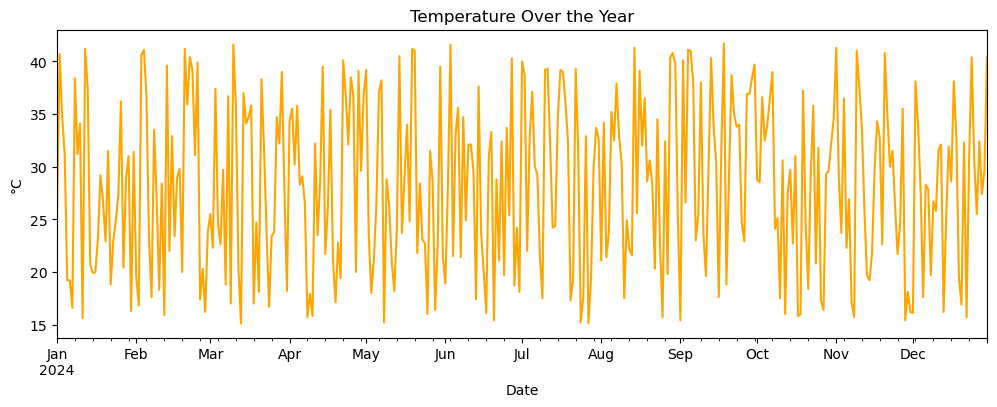

In [6]:
df_weather['Temperature'].plot(figsize=(12,4), color='orange')
plt.title('Temperature Over the Year')
plt.ylabel('°C')
plt.show()

- df_weather['Temperature'] — selects only the Temperature column from the dataset
- .plot.hist(...) — tells pandas to draw a histogram (shows how often values appear)
- bins=20 — divides the temperature range into 20 equal buckets/groups e.g. 15–16°C, 16–17°C etc
- color='tomato' — sets the bar color to red/tomato
- alpha=0.7 — sets transparency (0 = invisible, 1 = solid). 0.7 means slightly see-through
- plt.title(...) — adds a title at the top of the chart
- plt.xlabel(...) — labels the x-axis (horizontal)
- plt.show() — renders and displays the chart

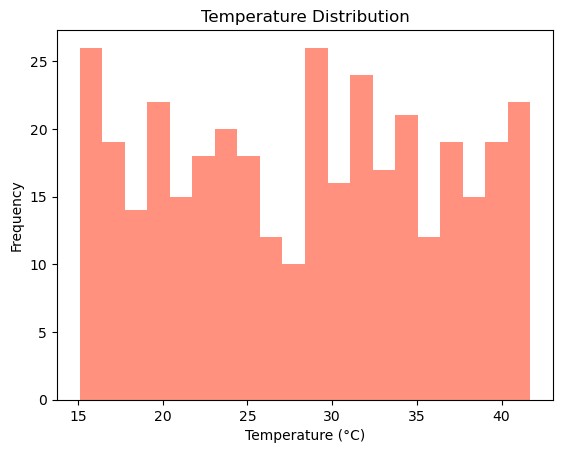

In [19]:

df_weather['Temperature'].plot.hist(bins=20, color='tomato', alpha=0.7)
plt.title('Temperature Distribution')
plt.xlabel('Temperature (°C)')
plt.show()

- df_weather.groupby('Month') — groups all rows by their month name
- ['Temperature'] — from each group, focus on the Temperature column
- .mean() — calculates the average temperature for each month
- .plot.bar(...) — draws a bar chart from the result
- color='steelblue' — sets bar color to steel blue
- plt.ylabel('°C') — labels the y-axis
- plt.xticks(rotation=45) — rotates the month labels 45 degrees so they don't overlap
- plt.show() — displays the chart

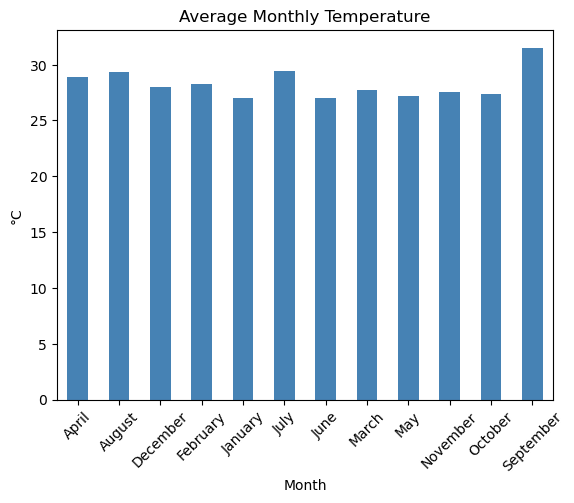

In [13]:
df_weather.groupby('Month')['Temperature'].mean().plot.bar(color='steelblue')
plt.title('Average Monthly Temperature')
plt.ylabel('°C')
plt.xticks(rotation=45)
plt.show()

- df_weather.plot.scatter(...) — draws a scatter plot (each row becomes one dot)
- x='Temperature' — puts Temperature on the horizontal axis
- y='Humidity' — puts Humidity on the vertical axis
- alpha=0.4 — makes dots 60% transparent so overlapping dots are still visible
- color='green' — sets dot color to green
- plt.title(...) — adds a title
- plt.show() — displays the chart

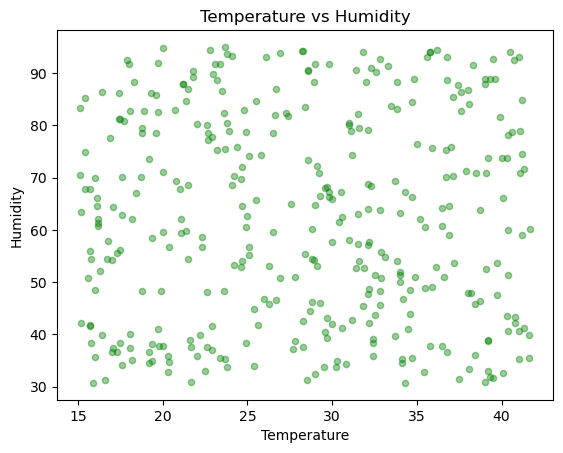

In [15]:
df_weather.plot.scatter(x='Temperature', y='Humidity', alpha=0.4, color='green')
plt.title('Temperature vs Humidity')
plt.show()

- df_weather.boxplot(...) — draws a box plot (shows spread and outliers of data)
- column='Wind_Speed' — the column we want to analyze
- by='Season' — splits the box plot into 4 groups, one per season
- plt.title(...) — adds your custom title
- plt.suptitle('') — pandas auto-adds an ugly default title, this clears/removes it
- plt.ylabel('km/h') — labels the y-axis with the wind speed unit
- plt.show() — displays the chart

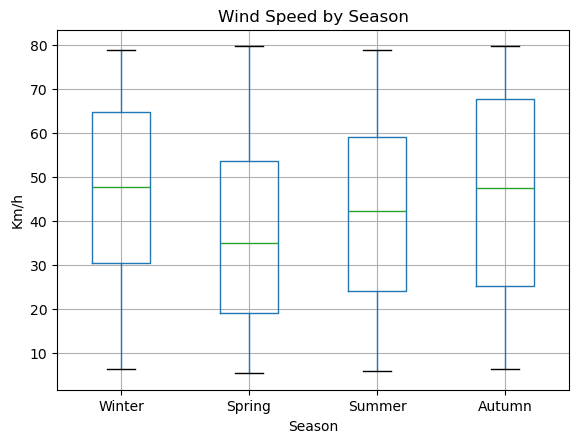

In [16]:
df_weather.boxplot(column='Wind_Speed', by='Season')
plt.title('Wind Speed by Season')
plt.suptitle('')
plt.ylabel('Km/h')
plt.show()

- df_weather['Condition'] — selects the Condition column
- .value_counts() — counts how many times each condition appears e.g. Sunny=120, Cloudy=95...
- .plot.pie(...) — draws a pie chart from those counts
- autopct='%1.1f%%' — displays the percentage on each slice formatted to 1 decimal place e.g. 35.2%
- figsize=(6,6) — makes the chart square (equal width and height) so the pie isn't oval
- plt.title(...) — adds a title
- plt.ylabel('') — pandas auto-adds a weird y-label on pie charts, this removes it
- plt.show() — displays the chart



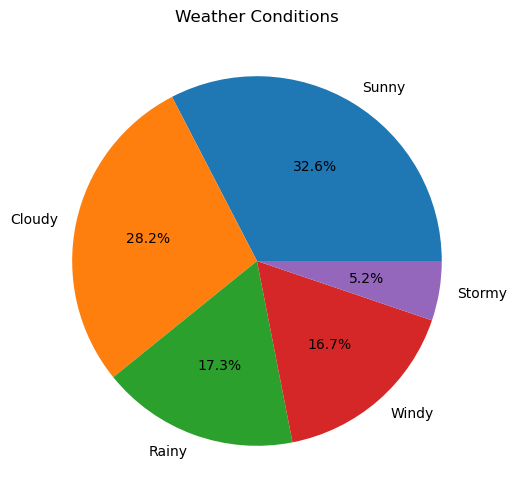

In [18]:
df_weather['Condition'].value_counts().plot.pie(autopct='%1.1f%%', figsize=(6,6))
plt.title('Weather Conditions')
plt.ylabel('')
plt.show()